In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r"D:\my project\codeit_datascience\data_science\regression\data science\Ship_Performance_Dataset.csv"
                )
data.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [3]:
# chek null values
data.isna().sum()

Date                         0
Ship_Type                  136
Route_Type                 136
Engine_Type                136
Maintenance_Status         136
Speed_Over_Ground_knots      0
Engine_Power_kW              0
Distance_Traveled_nm         0
Draft_meters                 0
Weather_Condition          136
Cargo_Weight_tons            0
Operational_Cost_USD         0
Revenue_per_Voyage_USD       0
Turnaround_Time_hours        0
Efficiency_nm_per_kWh        0
Seasonal_Impact_Score        0
Weekly_Voyage_Count          0
Average_Load_Percentage      0
dtype: int64

In [4]:
# drop all the null values
data = data.dropna()
data

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
5,2023-07-09,Fish Carrier,Long-haul,Heavy Fuel Oil (HFO),Fair,18.616196,2171.646567,723.304215,14.916320,Rough,1912.509751,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2729,2024-05-19,Container Ship,Long-haul,Heavy Fuel Oil (HFO),Good,24.257402,1813.474360,147.964296,10.378736,Moderate,1450.181358,266359.224719,820652.038923,34.433655,0.708172,1.352973,7,51.258697
2730,2024-05-26,Tanker,Long-haul,Diesel,Critical,15.649207,1662.426557,1175.942724,12.564046,Rough,451.670997,393827.995941,567287.169653,22.281638,0.356031,1.079178,2,92.926949
2731,2024-06-02,Tanker,Short-haul,Heavy Fuel Oil (HFO),Good,11.607997,2918.395972,239.990359,13.700906,Moderate,318.111891,237975.067292,731584.322921,47.152337,1.000265,1.284895,3,74.813114
2734,2024-06-23,Tanker,Transoceanic,Heavy Fuel Oil (HFO),Good,23.132643,2028.143572,619.236340,6.623856,Moderate,153.441965,25241.550250,799713.737211,14.335517,0.895670,0.902960,2,92.853622


In [5]:
# select only numeric datatypes
df = data.copy()

In [8]:
data = data.select_dtypes(['int','float'])
data

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
1,10.387580,1796.057415,1060.486382,14.653083,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,20.749747,1648.556685,658.874144,7.199261,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,21.055102,915.261795,1126.822519,11.789063,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,13.742777,1089.721803,1445.281159,9.727833,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
5,18.616196,2171.646567,723.304215,14.916320,1912.509751,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898
...,...,...,...,...,...,...,...,...,...,...,...,...
2729,24.257402,1813.474360,147.964296,10.378736,1450.181358,266359.224719,820652.038923,34.433655,0.708172,1.352973,7,51.258697
2730,15.649207,1662.426557,1175.942724,12.564046,451.670997,393827.995941,567287.169653,22.281638,0.356031,1.079178,2,92.926949
2731,11.607997,2918.395972,239.990359,13.700906,318.111891,237975.067292,731584.322921,47.152337,1.000265,1.284895,3,74.813114
2734,23.132643,2028.143572,619.236340,6.623856,153.441965,25241.550250,799713.737211,14.335517,0.895670,0.902960,2,92.853622


In [9]:
data.info()

<class 'pandas.DataFrame'>
Index: 2127 entries, 1 to 2735
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Speed_Over_Ground_knots  2127 non-null   float64
 1   Engine_Power_kW          2127 non-null   float64
 2   Distance_Traveled_nm     2127 non-null   float64
 3   Draft_meters             2127 non-null   float64
 4   Cargo_Weight_tons        2127 non-null   float64
 5   Operational_Cost_USD     2127 non-null   float64
 6   Revenue_per_Voyage_USD   2127 non-null   float64
 7   Turnaround_Time_hours    2127 non-null   float64
 8   Efficiency_nm_per_kWh    2127 non-null   float64
 9   Seasonal_Impact_Score    2127 non-null   float64
 10  Weekly_Voyage_Count      2127 non-null   int64  
 11  Average_Load_Percentage  2127 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 216.0 KB


In [10]:
# scaled the data since, values in some columns are very high, where some has small value
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
data_scaled = scaler.fit_transform(data)
data_scaled

array([[-1.65687933,  0.06316263,  0.03794152, ..., -0.40091973,
         0.41966299,  1.29542982],
       [ 0.72139537, -0.14332191, -0.67058043, ...,  1.3981811 ,
         1.57044493,  1.45576404],
       [ 0.79147906, -1.16985283,  0.15497135, ...,  1.27674966,
        -1.49830689, -0.61665395],
       ...,
       [-1.37677497,  1.63431121, -1.40957275, ...,  0.97996197,
        -0.73111894, -0.02170636],
       [ 1.2683062 ,  0.38805732, -0.74050921, ..., -0.34104105,
        -1.11471292,  1.22352389],
       [-1.39513862,  1.64857906,  1.57234831, ...,  0.99486326,
        -1.11471292, -0.6168669 ]], shape=(2127, 12))

In [13]:
data_scaled = pd.DataFrame(data_scaled, columns = data.columns)

In [14]:
data_scaled

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,-1.656879,0.063163,0.037942,1.650247,-1.562427,1.609770,1.335679,1.217541,-1.239500,-0.400920,0.419663,1.295430
1,0.721395,-0.143322,-0.670580,-0.971403,-1.534363,1.361956,-0.479685,0.433416,-0.720339,1.398181,1.570445,1.455764
2,0.791479,-1.169853,0.154971,0.642917,1.262606,0.030634,-1.615679,-1.097921,-0.215873,1.276750,-1.498307,-0.616654
3,-0.886811,-0.925628,0.716794,-0.082057,-1.386287,0.218169,0.565996,1.269137,1.343439,-1.446364,1.186851,0.336906
4,0.231713,0.588945,-0.556913,1.742832,1.576724,-0.515429,0.938808,0.323310,1.439868,1.508555,0.803257,-1.515265
...,...,...,...,...,...,...,...,...,...,...,...,...
2122,1.526455,0.087544,-1.571925,0.146878,0.747454,0.066262,1.101733,-0.416163,-0.202806,1.215422,0.803257,-1.647529
2123,-0.449256,-0.123906,0.241629,0.915493,-1.043557,0.972820,0.162576,-1.105149,-1.076557,0.268446,-1.114713,1.228585
2124,-1.376775,1.634311,-1.409573,1.315348,-1.283120,-0.135606,0.771582,0.304950,0.521949,0.979962,-0.731119,-0.021706
2125,1.268306,0.388057,-0.740509,-1.173784,-1.578485,-1.648566,1.024120,-1.555672,0.262423,-0.341041,-1.114713,1.223524


In [15]:
# since, scaled_data is 12D, decomposed to 2D using PCA (Principal composition analysis)
from sklearn.decomposition import PCA

In [16]:
pca = PCA(n_components=2)

In [18]:
pca_df = pca.fit_transform(data_scaled)
pca_df

array([[ 1.26547959,  0.6556992 ],
       [ 0.26621248,  1.43692635],
       [-1.26258632,  0.07479268],
       ...,
       [ 0.12207511,  0.00894222],
       [-0.31340407, -0.79840388],
       [ 0.45405111, -0.05028733]], shape=(2127, 2))

In [19]:
pca_df = pd.DataFrame(pca_df, columns=['A','B'])
pca_df

,A,B
0,1.265480,0.655699
1,0.266212,1.436926
2,-1.262586,0.074793
3,0.144650,0.783608
4,0.552155,-0.065001
...,...,...
2122,0.265636,0.449928
2123,0.563552,0.164804
2124,0.122075,0.008942
2125,-0.313404,-0.798404


<Axes: xlabel='A', ylabel='B'>

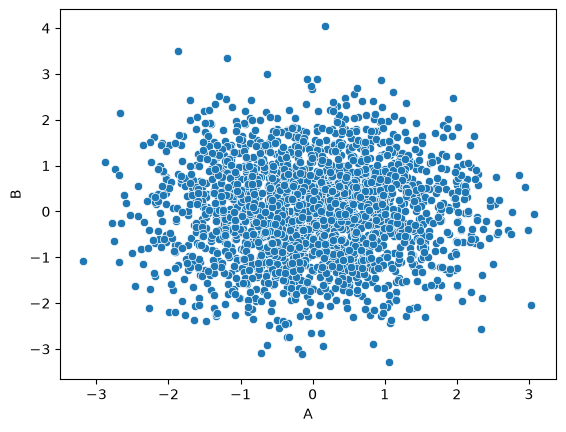

In [20]:
sns.scatterplot(x='A',y='B', data=pca_df)

In [21]:
# pca_df columns 'A','B' vlaue placed in 'df' dataset
df['A'] = pca_df['A']
df['B'] = pca_df['B']

In [22]:
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,A,B
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0.266212,1.436926
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,-1.262586,0.074793
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698,0.144650,0.783608
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581,0.552155,-0.065001
5,2023-07-09,Fish Carrier,Long-haul,Heavy Fuel Oil (HFO),Fair,18.616196,2171.646567,723.304215,14.916320,Rough,1912.509751,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898,-0.184037,-0.214248


<Axes: xlabel='A', ylabel='B'>

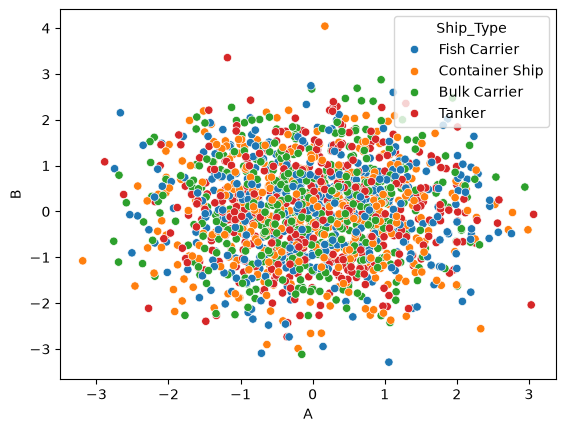

In [25]:
# plot 'df' dataset
sns.scatterplot(x='A',y='B', data=df, hue='Ship_Type')

In [29]:
# cluster the data with KMeans and wcss method
wcss=[]
from sklearn.cluster import KMeans

In [30]:
for k in range(2,10):
    model = KMeans(n_clusters=k)
    model.fit(pca_df)
    wcss.append(model.inertia_)

In [31]:
wcss

[3225.143102644233,
 2113.04186650233,
 1674.926331371625,
 1415.1369898589223,
 1151.5859944649974,
 1005.2963824348598,
 889.7066220438335,
 803.1219733599673]

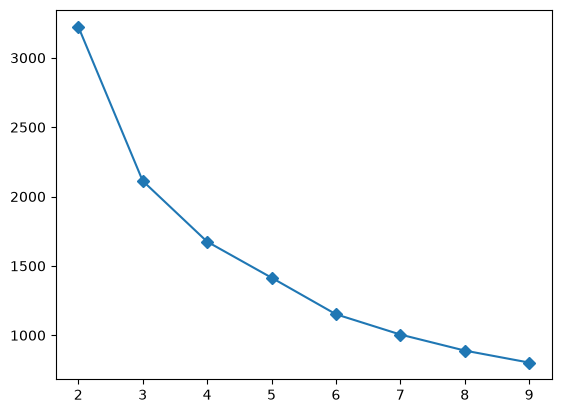

In [32]:
plt.plot(range(2,10), wcss, marker='D')

In [70]:
# from tthe graph, Elbo method, it is difficut to find the cluster number, i might take cluster as 3 or 4 or 5
# for better cluster number decision use SILHOUTTE method


In [37]:
from sklearn.metrics import silhouette_score

In [43]:
cluster_range = range(2,10)
sil_score = []

In [45]:
for c in cluster_range:
    km = KMeans(n_clusters=c)
    labels = km.fit_predict(pca_df)
    score = silhouette_score(pca_df, labels)
    sil_score.append(score)

In [46]:
sil_score

[0.30348724222078993,
 0.3313757598742225,
 0.32360304264094264,
 0.30186920781513443,
 0.32409200187699416,
 0.31046011880380714,
 0.31652053190318385,
 0.3166603358478616]

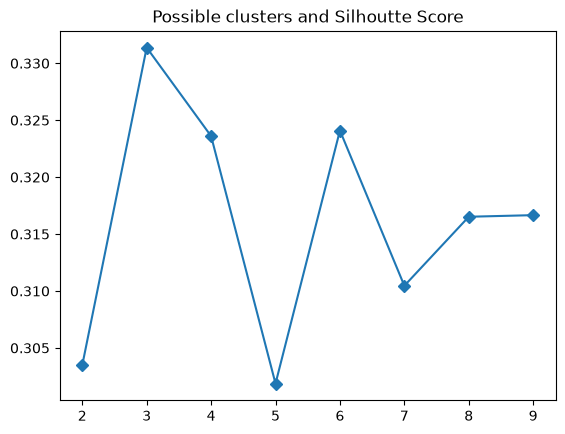

In [48]:
plt.title("Possible clusters and Silhoutte Score")
plt.plot(range(2,10), sil_score, marker='D')

In [59]:
# take n_cluster = 3, 
kmeans = KMeans(n_clusters= 3)
kmeans.fit_predict(pca_df)


array([2, 0, 1, ..., 2, 1, 2], shape=(2127,), dtype=int32)

In [62]:
pca_df['cluster'] = kmeans.fit_predict(pca_df)

In [68]:
pca_df.head()

,A,B,cluster
0,1.265480,0.655699,0
1,0.266212,1.436926,1
2,-1.262586,0.074793,2
3,0.144650,0.783608,1
4,0.552155,-0.065001,0


<Axes: xlabel='A', ylabel='B'>

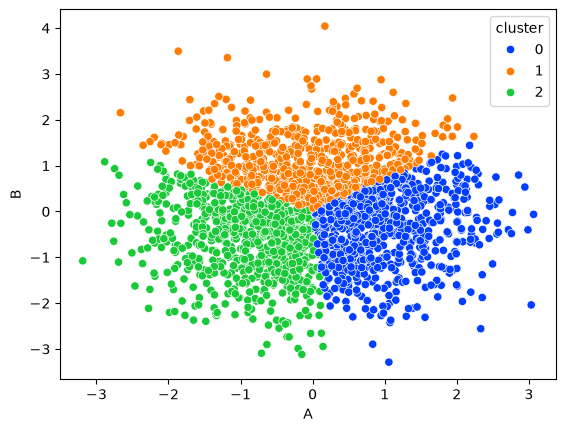

In [69]:
sns.scatterplot(x='A',y='B', data=pca_df, hue='cluster', palette='bright')

In [71]:
df['clusters'] = pca_df['cluster']

In [72]:
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,...,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,A,B,clusters
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,...,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0.266212,1.436926,1.0
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,...,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,-1.262586,0.074793,2.0
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,...,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698,0.144650,0.783608,1.0
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,...,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581,0.552155,-0.065001,0.0
5,2023-07-09,Fish Carrier,Long-haul,Heavy Fuel Oil (HFO),Fair,18.616196,2171.646567,723.304215,14.916320,Rough,...,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898,-0.184037,-0.214248,2.0


In [74]:
df.groupby('clusters')['Ship_Typ'].value_counts()

clusters  Ship_Type     
0.0       Bulk Carrier      143
          Fish Carrier      142
          Container Ship    136
          Tanker            136
1.0       Bulk Carrier      147
          Tanker            129
          Fish Carrier      127
          Container Ship    123
2.0       Bulk Carrier      149
          Container Ship    147
          Tanker            134
          Fish Carrier      130
Name: count, dtype: int64

In [77]:
df.groupby('clusters')[['A','B']].min()

,A,B
clusters,,
0.0,0.032429,-3.287422
1.0,-2.667175,0.043054
2.0,-3.189513,-3.118007


In [85]:
df.groupby(['clusters','Ship_Type'])['Distance_Traveled_nm'].agg(['min','max','mean','std'])

min          max         mean         std
clusters Ship_Type                                                      
0.0      Bulk Carrier    62.392629  1997.838275   972.550952  578.416349
         Container Ship  50.433150  1993.573031  1070.726217  589.398748
         Fish Carrier    68.826439  1996.830088  1100.401139  518.348060
         Tanker          50.524214  1988.335978  1126.292769  531.647537
1.0      Bulk Carrier    63.129592  1941.573497   978.836438  578.659025
         Container Ship  89.986998  1987.845825   999.852388  587.663046
         Fish Carrier    68.906380  1992.640818  1060.073561  563.924164
         Tanker          54.676083  1990.130754  1066.002283  544.813291
2.0      Bulk Carrier    52.286608  1996.554335  1053.457137  592.399392
         Container Ship  59.639722  1995.417244  1060.939970  589.957207
         Fish Carrier    52.566168  1971.476969  1050.835798  568.135833
         Tanker          63.595957  1989.845755   967.021971  562.264524

<Axes: xlabel='Distance_Traveled_nm', ylabel='Density'>

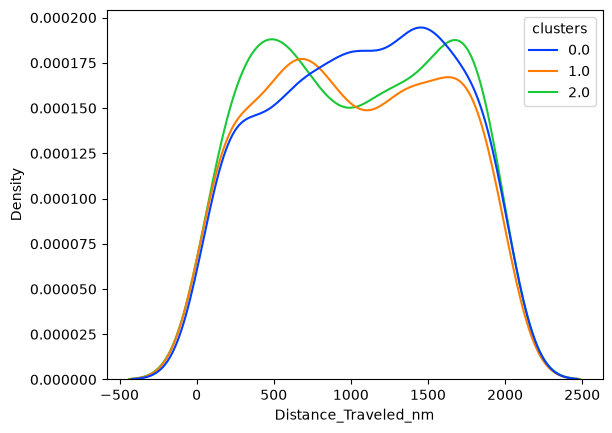

In [83]:
sns.kdeplot(x='Distance_Traveled_nm', data=df, hue='clusters', palette='bright')

<Axes: xlabel='A', ylabel='B'>

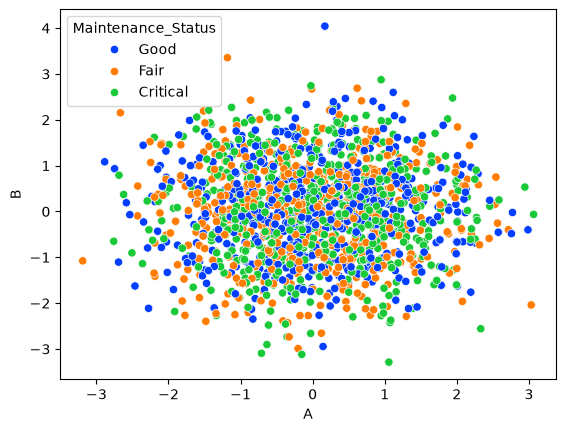

In [87]:
sns.scatterplot(x='A',y='B', data=df, hue='Maintenance_Status', palette='bright')

In [88]:
df.head(2)

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,...,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage,A,B,clusters
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,...,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372,0.266212,1.436926,1.0
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,...,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244,-1.262586,0.074793,2.0


In [95]:
# which cluster has travelled max distance
df.groupby('clusters')['Distance_Traveled_nm'].max()

clusters
0.0    1997.838275
1.0    1992.640818
2.0    1996.554335
Name: Distance_Traveled_nm, dtype: float64

In [94]:
# which cluster ship has travelled in rough condition
df.groupby('clusters')['Weather_Condition'].value_counts()

clusters  Weather_Condition
0.0       Moderate             197
          Rough                185
          Calm                 175
1.0       Moderate             183
          Calm                 178
          Rough                165
2.0       Calm                 206
          Moderate             188
          Rough                166
Name: count, dtype: int64

In [96]:
# save the dataset
df.to_csv('data_clustered.csv', index=False)